In [4]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
words = open('names.txt','r',).read().splitlines()

building a bigram model
bigram -> only concerned with 2 characters at a time

In [ ]:
for w in words:
    for ch1, ch2 in zip(w,w[1:]):
        print(ch1,ch2)

In [ ]:
w = words[0]
list(w)

#print(words[:10])

In [6]:
N = torch.zeros((27,27), dtype = torch.int32) # 26 alphabets+ E,S symbols



In [54]:
#lookup table for all chars

chars =sorted(list(set(''.join(words)))) # set removes duplicates
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}




In [55]:

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1

In [ ]:
itos = {i:s for s,i in stoi.items()}
itos

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

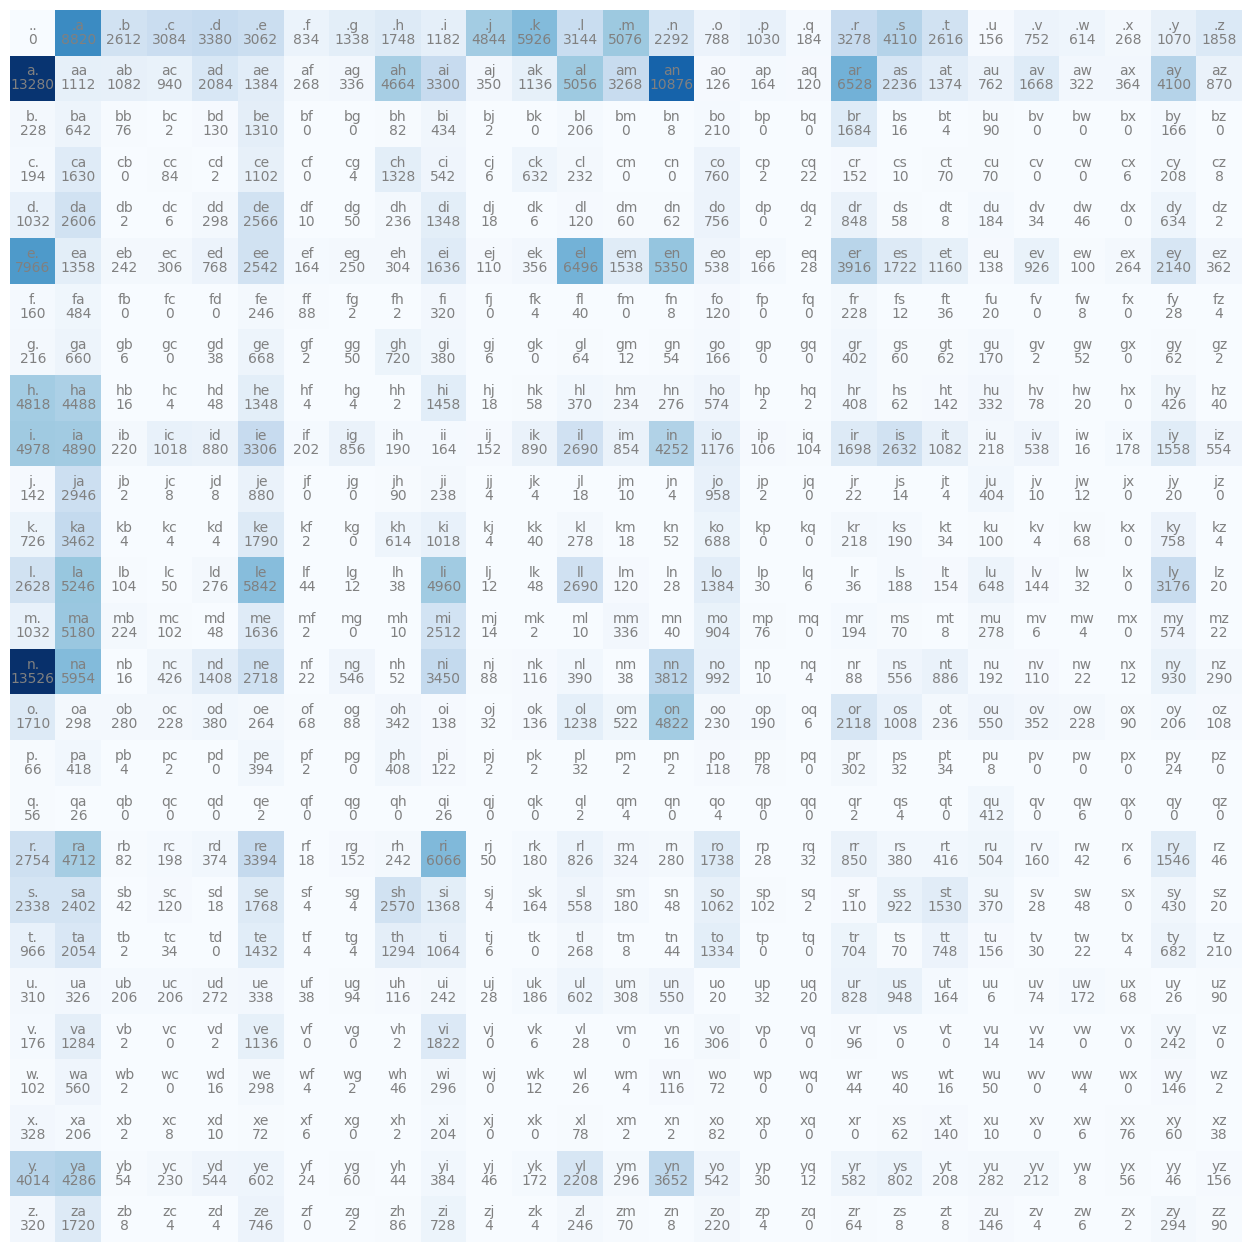

In [82]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i]+itos[j]
        plt.text(j,i,chstr,ha="center",va="bottom",color = "gray")
        plt.text(j,i,N[i,j].item(),ha = "center", va  = 'top',color = 'gray')
plt.axis('off')        


In [78]:
P = (N+1).float()
P/= P.sum(1, keepdim =True)

### building a random prob distribution, then sampling from it


In [72]:

g=torch.Generator().manual_seed(42)
ix = torch.multinomial(p,1,replacement =True,generator =g).item()# sample indices from p
itos[ix]

'a'

In [73]:
g=torch.Generator().manual_seed(42)
p=torch.rand(3, generator=g) # 3 rand nos from 0 to 1
p=p/p.sum() # normalize the 3 rand nos to add up to 1
p # now p is a probability vector

tensor([0.4047, 0.4197, 0.1756])

In [74]:
torch.multinomial(p,20,replacement =True,generator =g)# sample indices from p


tensor([1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 2])

In [75]:
g=torch.Generator().manual_seed(42)
for i in range(5):

    out = []
    ix = 0 # init index at <.>

    while True:
        p = P[ix]
       
        ix = torch.multinomial(p,1,replacement =True,generator =g).item()# sampling the next character from the distribution
        out.append(itos[ix])
    
        if ix==0: # after sampling the end token end the loop
            break  
    print(''.join(out))      


anugeenvi.
s.
mabidushan.
stan.
silaylelaremah.


In [ ]:
log_likelihood = 0.0
n = 0
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob= torch.log(prob)
        log_likelihood += logprob   
        n +=1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob: .4f}')
        nll = -log_likelihood # lower is better
print(f'{log_likelihood=}')  
print(f'{nll=}')
print(f'{nll/n=}')      

.a: 0.1376 -1.9832
an: 0.1604 -1.8299
nd: 0.0384 -3.2594
dr: 0.0770 -2.5633
re: 0.1335 -2.0135
ej: 0.0027 -5.9087
jq: 0.0002 -8.6703
q.: 0.0998 -2.3043
log_likelihood=tensor(-28.5326)
nll=tensor(28.5326)
nll/n=tensor(3.5666)


### creating training set of all the bigrams


In [ ]:
xs , ys = [],[] # inputs and targets
# input is the current char, target is the next char(sucessive)
for w in words[:1]:
    chs = ['.']+list(w)+['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)



In [92]:
xs


tensor([ 0,  5, 13, 13,  1])

In [93]:
ys

tensor([ 5, 13, 13,  1,  0])

In [94]:
import torch.nn.functional as F

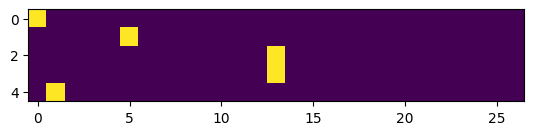

In [99]:
xenc = F.one_hot(xs, num_classes = 27).float() # using one hot encoding to feed vectors to nn
xenc.shape
plt.imshow(xenc)

In [ ]:

# creating neurons
W = torch.randn((27,27))  # 27 neurons created, weight matrix
xenc @ W # 5x27 output matrix, one score for each possible next character

tensor([[-0.3363, -0.4921, -0.5832, -0.5906, -1.8963, -0.0472, -1.5419, -1.6415,
          0.7440, -0.1888, -0.4989, -0.8532, -0.7876, -0.8822,  0.2321,  1.4450,
         -0.7483, -1.2207,  1.0265,  0.9192,  0.4982, -0.7904, -0.2232, -1.7122,
         -0.6679,  0.8924, -0.8657],
        [-1.2032,  0.2663,  1.3279, -0.4692,  0.7845,  1.0801, -1.1111,  1.1786,
          1.9869, -0.8243, -2.3998, -0.5057,  1.1632, -1.3012, -0.5660,  1.4504,
          0.6921, -0.8630,  0.4203, -0.6317,  0.1455,  1.9180, -0.6615,  0.1520,
         -0.0221, -0.1551,  0.3380],
        [ 0.9954, -0.3332, -0.6441,  0.9966,  1.8240, -1.5557, -0.3588, -1.1107,
         -2.9578,  0.7389, -1.3116, -0.5651, -1.5487, -1.7307,  0.4195,  0.0106,
          0.2963,  2.9625, -0.2402, -0.7406, -1.4781, -1.0201, -0.9434, -1.0091,
          2.1087, -0.1316, -0.5887],
        [ 0.9954, -0.3332, -0.6441,  0.9966,  1.8240, -1.5557, -0.3588, -1.1107,
         -2.9578,  0.7389, -1.3116, -0.5651, -1.5487, -1.7307,  0.4195,  0.0106

In [ ]:
logits = (xenc @ W)  # raw scores
counts = logits.exp()# counts are now positive log counts
probs = counts / counts.sum(1, keepdims = True)  # normalize the counts to prob distri.
probs

tensor([[0.0266, 0.0228, 0.0208, 0.0207, 0.0056, 0.0356, 0.0080, 0.0072, 0.0785,
         0.0309, 0.0227, 0.0159, 0.0170, 0.0154, 0.0470, 0.1582, 0.0177, 0.0110,
         0.1041, 0.0935, 0.0614, 0.0169, 0.0298, 0.0067, 0.0191, 0.0911, 0.0157],
        [0.0062, 0.0267, 0.0773, 0.0128, 0.0449, 0.0603, 0.0067, 0.0666, 0.1494,
         0.0090, 0.0019, 0.0124, 0.0656, 0.0056, 0.0116, 0.0874, 0.0409, 0.0086,
         0.0312, 0.0109, 0.0237, 0.1395, 0.0106, 0.0239, 0.0200, 0.0175, 0.0287],
        [0.0511, 0.0135, 0.0099, 0.0512, 0.1170, 0.0040, 0.0132, 0.0062, 0.0010,
         0.0395, 0.0051, 0.0107, 0.0040, 0.0033, 0.0287, 0.0191, 0.0254, 0.3653,
         0.0148, 0.0090, 0.0043, 0.0068, 0.0074, 0.0069, 0.1555, 0.0166, 0.0105],
        [0.0511, 0.0135, 0.0099, 0.0512, 0.1170, 0.0040, 0.0132, 0.0062, 0.0010,
         0.0395, 0.0051, 0.0107, 0.0040, 0.0033, 0.0287, 0.0191, 0.0254, 0.3653,
         0.0148, 0.0090, 0.0043, 0.0068, 0.0074, 0.0069, 0.1555, 0.0166, 0.0105],
        [0.0070, 0.0056,